Step 1: Load Datasets from Drive & Identify Features

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bollywood_full_1950-2019.csv')


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4330 entries, 0 to 4329
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title_x           4330 non-null   object 
 1   imdb_id           4330 non-null   object 
 2   poster_path       3580 non-null   object 
 3   wiki_link         4330 non-null   object 
 4   title_y           4330 non-null   object 
 5   original_title    4330 non-null   object 
 6   is_adult          4330 non-null   int64  
 7   year_of_release   4330 non-null   object 
 8   runtime           4330 non-null   object 
 9   genres            4330 non-null   object 
 10  imdb_rating       4317 non-null   float64
 11  imdb_votes        4317 non-null   float64
 12  story             4065 non-null   object 
 13  summary           4329 non-null   object 
 14  tagline           685 non-null    object 
 15  actors            4320 non-null   object 
 16  wins_nominations  1344 non-null   object 



`NOTE:`

For our content-based recommender, we will use the following columns from the dataset as features to describe each movie's content:

* `title`: The name of the movie.
* `genres`: Categories the movie belongs to.
* `story`: The longer plot description.
* `summary`: A shorter plot summary.
* `actors`: The main actors involved.

We will *not* use `imdb_rating` or `imdb_votes` directly to calculate similarity, but they are useful for EDA. The `imdb_id` is crucial for merging but not for the final 'tags'.

Step 2: Exploring the dataset

In [39]:
df.shape

(4330, 18)

In [40]:
df.describe()

,is_adult,imdb_rating,imdb_votes
count,4330.0,4317.000000,4317.000000
mean,0.0,5.911744,2387.874913
std,0.0,1.330077,9404.126400
min,0.0,0.000000,0.000000
25%,0.0,5.100000,32.000000
50%,0.0,6.100000,131.000000
75%,0.0,6.900000,966.000000
max,0.0,9.400000,310481.000000


In [41]:
df.head(5)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112.0,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73.0,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549.0,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891.0,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280.0,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)


In [42]:
df.tail(5)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
4325,Samadhi (1950 film),tt0268614,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Samadhi_(1950_film),Samadhi,Samadhi,0,1950,165,Drama,6.1,21.0,The story is based on the true incident at INA...,The story is based on the true incident at INA...,NaN,Ashok Kumar|Nalini Jaywant|Kuldip Kaur|Shyam|M...,NaN,NaN
4326,Sangram (1950 film),tt0244182,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Sangram_(1950_film),Sangram,Sangram,0,1950,139,Drama,6.2,20.0,After the death of his wife a policeman fails...,After the death of his wife a policeman fails...,NaN,Ashok Kumar|Nalini Jaywant|Nawab|Sajjan|Tiwari...,NaN,NaN
4327,Sargam (1950 film),tt0269826,NaN,https://en.wikipedia.org/wiki/Sargam_(1950_film),Melody,Sargam,0,1950,135,Drama|Family,6.8,21.0,NaN,Add a Plot »,NaN,Raj Kapoor|Rehana|Om Prakash|David Abraham|Rad...,NaN,4 February 1957 (Iran)
4328,Sheesh Mahal (1950 film),tt0243555,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Sheesh_Mahal_(19...,Sheesh Mahal,Sheesh Mahal,0,1950,144,Drama,7.0,13.0,Thakur Jaspal Singh lives in the prestigious a...,Thakur Jaspal Singh lives in the prestigious a...,NaN,Sohrab Modi|Naseem Banu|Pushpa Hans|Nigar Sult...,NaN,NaN
4329,Meena Bazaar (film),tt0213081,NaN,https://en.wikipedia.org/wiki/Meena_Bazaar_(19...,Meena Bazaar,Meena Bazaar,0,1950,\N,Drama,7.0,9.0,NaN,Add a Plot »,NaN,NaN,NaN,NaN


In [43]:
df.dtypes

,0
title_x,object
imdb_id,object
poster_path,object
wiki_link,object
title_y,object
original_title,object
is_adult,int64
year_of_release,object
runtime,object
genres,object


In [44]:
df.isnull().sum()


,0
title_x,0
imdb_id,0
poster_path,750
wiki_link,0
title_y,0
original_title,0
is_adult,0
year_of_release,0
runtime,0
genres,0


Step 3: Data Visualization

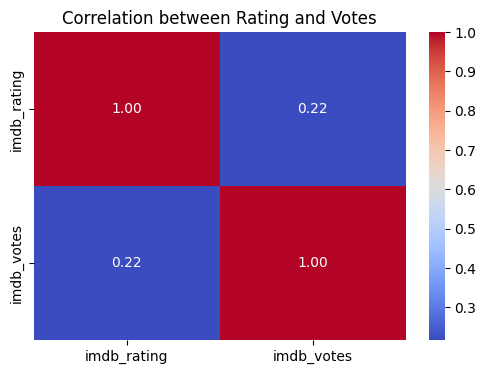

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_df = df[['imdb_rating', 'imdb_votes']].copy()
# Calculate correlation
correlation_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Rating and Votes')
plt.show()

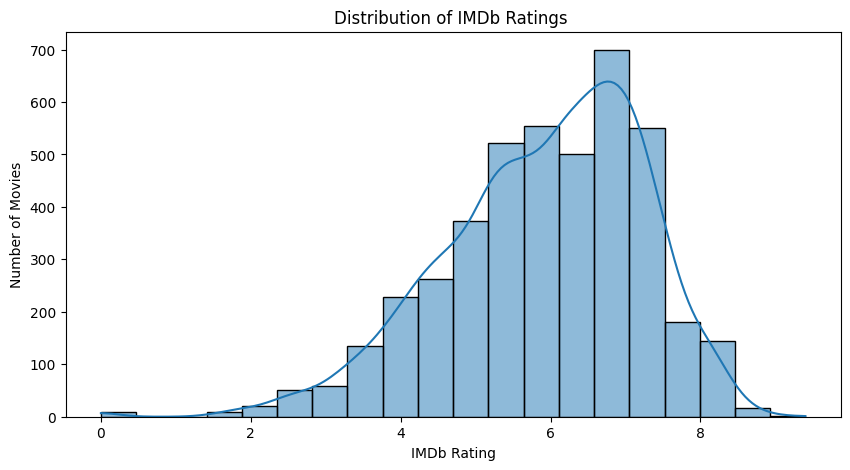

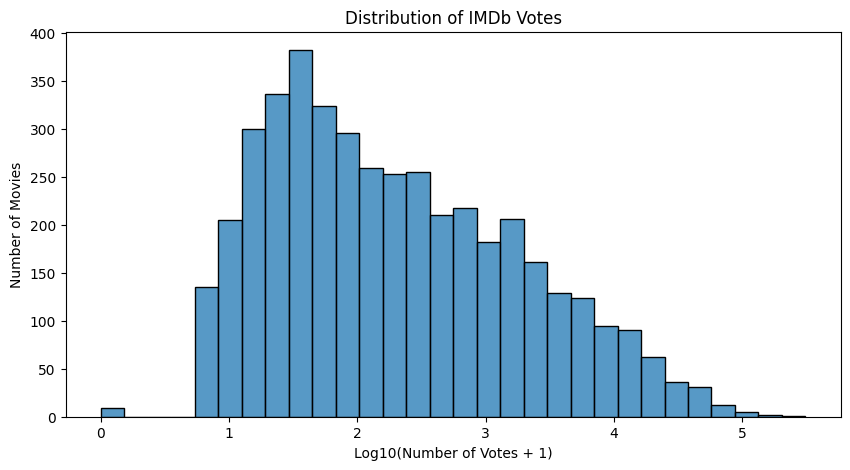

In [46]:


# Plot distribution of IMDb Ratings
plt.figure(figsize=(10, 5))
sns.histplot(df['imdb_rating'].dropna(), kde=True, bins=20) # dropna() handles missing ratings for plotting
plt.title('Distribution of IMDb Ratings ')
plt.xlabel('IMDb Rating')
plt.ylabel('Number of Movies')
plt.show()

# Plot distribution of IMDb Votes (use log scale due to skewness)
plt.figure(figsize=(10, 5))
# Add a small constant to avoid log(0) if votes can be 0
sns.histplot(np.log10(df['imdb_votes'].dropna() + 1), kde=False, bins=30)
plt.title('Distribution of IMDb Votes')
plt.xlabel('Log10(Number of Votes + 1)')
plt.ylabel('Number of Movies')
plt.show()

Step 4: Data Preprocessing -  Handle missing values, select relevant features, and prepare data for modeling.

In [47]:
# Select the columns needed for the recommender
# Use .copy() to prevent modifying the original DataFrame accidentally
df_recommender = df[['title_x', 'genres', 'story', 'summary', 'actors']].copy()

# Rename 'title_x' to 'title'
df_recommender.rename(columns={'title_x': 'title'}, inplace=True)

print("--- Selected and Renamed DataFrame ---")
df_recommender.info() # Check the structure of your new DataFrame
print("\nFirst 5 rows:")
print(df_recommender.head())

--- Selected and Renamed DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4330 entries, 0 to 4329
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    4330 non-null   object
 1   genres   4330 non-null   object
 2   story    4065 non-null   object
 3   summary  4329 non-null   object
 4   actors   4320 non-null   object
dtypes: object(5)
memory usage: 169.3+ KB

First 5 rows:
                                  title            genres  \
0              Uri: The Surgical Strike  Action|Drama|War   
1                         Battalion 609               War   
2  The Accidental Prime Minister (film)   Biography|Drama   
3                       Why Cheat India       Crime|Drama   
4                       Evening Shadows             Drama   

                                               story  \
0  Divided over five chapters  the film chronicle...   
1  The story revolves around a cricket match betw...   
2  B

In [48]:
print("--- Handling Missing Values ---")
print("Null counts BEFORE imputation:")
# Show missing values in the columns we care about
print(df_recommender.isnull().sum())

# Define the text columns where we need to fill missing values
text_cols_to_fill = ['genres', 'story', 'summary', 'actors']

# Fill NaN values in these specific columns with an empty string
for col in text_cols_to_fill:
    df_recommender[col] = df_recommender[col].fillna('')

print("\nNull counts AFTER imputation (should be 0 for filled columns):")
print(df_recommender.isnull().sum())

--- Handling Missing Values ---
Null counts BEFORE imputation:
title        0
genres       0
story      265
summary      1
actors      10
dtype: int64

Null counts AFTER imputation (should be 0 for filled columns):
title      0
genres     0
story      0
summary    0
actors     0
dtype: int64


Step 5: Feature engineering

We'll combine the cleaned genres, story, summary, and actors text into one column. We'll also clean the genres and actors text first (remove spaces within names, replace '|' with a space) and convert the final tags to lowercase.



In [49]:
import re # Import regular expressions library, useful for text cleaning

print("--- Step 5: Feature Engineering ---")

# 1. Define the cleaning function for genres and actors
def clean_text_data(text):
    """Removes spaces within names/genres and replaces '|' delimiter with a space."""
    if isinstance(text, str):
        # Remove spaces (e.g., 'Sanjeev Kumar' -> 'SanjeevKumar')
        cleaned = text.replace(' ', '')
        # Replace the '|' delimiter (often used for actors) with a space
        cleaned = cleaned.replace('|', ' ')
        return cleaned
    return '' # Return empty string if input is not text

print("Applying cleaning function to 'genres' and 'actors'...")
# 2. Apply the cleaning function to create new cleaned columns
df_recommender['genres_clean'] = df_recommender['genres'].apply(clean_text_data)
df_recommender['actors_clean'] = df_recommender['actors'].apply(clean_text_data)

# 3. Combine relevant columns into the 'tags' column
print("Combining features into the 'tags' column...")
df_recommender['tags'] = (df_recommender['story'] + ' ' +
                         df_recommender['summary'] + ' ' +
                         df_recommender['genres_clean'] + ' ' +
                         df_recommender['actors_clean'])

# 4. Convert the 'tags' column to lowercase for consistency
print("Converting tags to lowercase...")
df_recommender['tags'] = df_recommender['tags'].str.lower()

# --- Verification ---
print("\nCreated and cleaned the 'tags' column successfully.")
print("\n--- Sample Tag (for the first movie) ---")
# Display one example tag to see the result
print(df_recommender.loc[0, 'tags'])

# --- Display DataFrame info again to confirm 'tags' column ---
print("\n--- DataFrame Info after adding 'tags' ---")
df_recommender.info()

--- Step 5: Feature Engineering ---
Applying cleaning function to 'genres' and 'actors'...
Combining features into the 'tags' column...
Converting tags to lowercase...

Created and cleaned the 'tags' column successfully.

--- Sample Tag (for the first movie) ---
divided over five chapters  the film chronicles the events of the surgical strike conducted by the indian military against suspected militants in pakistan occupied kashmir. it tells the story of the 11 tumultuous events over which the operation was carried out. indian army special forces carry out a covert operation to avenge the killing of fellow army men at their base by a terrorist group. indian army special forces execute a covert operation  avenging the killing of fellow army men at their base by a terrorist group. action drama war vickykaushal pareshrawal mohitraina yamigautam kirtikulhari rajitkapoor ivanrodrigues manasiparekh swaroopsampat rivaarora yogeshsoman fareedahmed akashdeeparora kallolbanerjee 

--- DataFrame I

Step 6: Encoding with TF - IDF

This step converts the raw text in your tags column into a numerical matrix. TF-IDF (Term Frequency-Inverse Document Frequency) assigns a score to each word in each movie's tags, indicating how important that word is to that specific movie relative to the entire collection of movies.

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- Step 6: Encoding Text using TF-IDF ---")

# 1. Initialize the TF-IDF Vectorizer
#    - max_features=5000: Limit the vocabulary to the 5000 most frequent words.
#    - stop_words='english': Remove common English words (like 'the', 'a', 'is').
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

print("Initializing TF-IDF Vectorizer (max_features=5000, stop_words='english')...")

# 2. Fit the vectorizer to your 'tags' data and transform the data
#    - fit_transform() learns the vocabulary and converts the text into a matrix.
print("Fitting TF-IDF to the 'tags' data and transforming...")
vectorized_data = tfidf_vectorizer.fit_transform(df_recommender['tags'])

# --- Verification ---
print("\nTF-IDF transformation complete.")
print(f"Shape of the vectorized data matrix: {vectorized_data.shape}")
print("(Rows = Number of Movies, Columns = Number of Unique Words in Vocabulary)")

--- Step 6: Encoding Text using TF-IDF ---
Initializing TF-IDF Vectorizer (max_features=5000, stop_words='english')...
Fitting TF-IDF to the 'tags' data and transforming...

TF-IDF transformation complete.
Shape of the vectorized data matrix: (4330, 5000)
(Rows = Number of Movies, Columns = Number of Unique Words in Vocabulary)


Step 7: Calculating the cosine similarity.

Now we'll use the numerical vectors created by TF-IDF to compute the cosine similarity between every pair of movies. This score (ranging from 0 to 1) tells us how similar the content of two movies is based on the words they share. A score closer to 1 means higher similarity.

In [51]:
from sklearn.metrics.pairwise import cosine_similarity

print("--- Step 7: Calculating Cosine Similarity ---")

# 1. Calculate the similarity matrix using the vectorized data
#    This compares each movie vector with every other movie vector.
print("Calculating the similarity matrix...")
similarity_matrix = cosine_similarity(vectorized_data)

# --- Verification ---
print("\nCosine similarity calculation complete.")
print(f"Shape of the similarity matrix: {similarity_matrix.shape}")
# This should be (number_of_movies, number_of_movies).


--- Step 7: Calculating Cosine Similarity ---
Calculating the similarity matrix...

Cosine similarity calculation complete.
Shape of the similarity matrix: (4330, 4330)


Step 8: Building the Recommendation Function.

This function will take a movie title as input, find its corresponding row in the similarity_matrix, identify the movies with the highest similarity scores, and return their titles.

In [52]:
import pandas as pd

print("--- Step 8: Building the Recommendation Function ---")

# 1. Create a mapping from movie title to its index
#    This allows us to quickly find a movie's row number in the matrix.
#    Need to handle potential duplicate titles first by dropping them
#    while keeping the first occurrence for the index lookup.
df_recommender_unique = df_recommender.drop_duplicates(subset='title')
indices = pd.Series(df_recommender_unique.index, index=df_recommender_unique['title'])

# 2. Define the recommendation function
def recommend(movie_title):
    """Recommends top 10 similar movies based on content similarity."""
    try:
        # Get the index of the movie that matches the title from our mapping
        idx = indices[movie_title]
    except KeyError:
        # Handle the case where the movie title isn't found
        return [f"Sorry, the movie '{movie_title}' was not found in the dataset."]

    # Get the similarity scores of all movies with the input movie
    # (This selects the row corresponding to 'idx' from the similarity matrix)
    sim_scores = list(enumerate(similarity_matrix[idx]))

    # Sort the movies based on the similarity scores (highest score first)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the top 10 most similar movies
    # (Start from index 1 to exclude the movie itself, which has a score of 1.0)
    sim_scores = sim_scores[1:11]

    # Get the original indices of these top 10 movies
    movie_indices = [i[0] for i in sim_scores]

    # Return the titles corresponding to these indices
    # Use .iloc on the original df_recommender to fetch titles by index
    return df_recommender['title'].iloc[movie_indices].tolist()

print("Recommendation function 'recommend(movie_name)' is ready to use!")

--- Step 8: Building the Recommendation Function ---
Recommendation function 'recommend(movie_name)' is ready to use!


Step 9: Qualitative Evaluation and Testing

Now, testing the recommend() function we just built. Call it with a few movie titles from your dataset (df_recommender['title']) and see if the recommendations make sense based on genre, actors, or plot similarity. This is how we evaluate recommenders qualitatively.

In [53]:
print("--- Step 9: Testing the Recommender (Qualitative Evaluation) ---")

# Test Case 1: Choose a well-known movie from the dataset (e.g., Sholay)
movie1 = "Sholay"
if movie1 in indices: # Check if the movie exists in our index map
    print(f"\nRecommendations for '{movie1}':")
    recommendations1 = recommend(movie1)
    for i, title in enumerate(recommendations1):
        print(f"{i+1}. {title}")
else:
    print(f"\nMovie '{movie1}' not found for testing.")

# Test Case 2: Choose another movie (e.g., a more recent one if available)
movie2 = "Dangal" # Example, check if it's in your dataset
if movie2 in indices:
    print(f"\nRecommendations for '{movie2}':")
    recommendations2 = recommend(movie2)
    for i, title in enumerate(recommendations2):
        print(f"{i+1}. {title}")
else:
    print(f"\nMovie '{movie2}' not found for testing.")

# Test Case 3: Try another movie
movie3 = "3 Idiots" # Example, check if it's in your dataset
if movie3 in indices:
    print(f"\nRecommendations for '{movie3}':")
    recommendations3 = recommend(movie3)
    for i, title in enumerate(recommendations3):
      print(f"{i+1}. {title}")
else:
    print(f"\nMovie '{movie3}' not found for testing.")

print("\n--- Evaluation: Review the recommendations above. Do they seem logical? ---")

--- Step 9: Testing the Recommender (Qualitative Evaluation) ---

Recommendations for 'Sholay':
1. Sholay
2. Ramgarh Ke Sholay
3. Aag (2007 film)
4. Do Waqt Ki Roti
5. Pratigya (1975 film)
6. Mardon Wali Baat
7. Sitapur Ki Geeta
8. Parvarish (1977 film)
9. Veerappan (2016 film)
10. Gabbar Is Back

Movie 'Dangal' not found for testing.

Recommendations for '3 Idiots':
1. Abhi To Jee Lein
2. Haasil
3. Student of the Year 2
4. Fukrey
5. Awaara
6. Strings of Passion
7. 99 (2009 film)
8. Mumbai Delhi Mumbai
9. Jo Jeeta Wohi Sikandar
10. Kucch To Hai

--- Evaluation: Review the recommendations above. Do they seem logical? ---


Step 10: Saving the model.

Finally, save the similarity_matrix and the processed df_recommender DataFrame (which contains the titles needed for the function). We use the pickle library for this, allowing you to load these objects later (e.g., in a Streamlit app) without rerunning all the calculations.

In [54]:
import pickle

print("--- Step 10: Saving Model Files ---")

try:
    # Save the DataFrame (containing titles) as a dictionary for robustness
    # We use df_recommender which has the 'title' and original index info
    pickle.dump(df_recommender.to_dict(), open('movies_dict.pkl', 'wb'))

    # Save the similarity matrix (the core model)
    pickle.dump(similarity_matrix, open('similarity.pkl', 'wb'))

    print("\nSuccessfully saved:")
    print("1. 'movies_dict.pkl' (contains movie titles and data)")
    print("2. 'similarity.pkl' (contains the computed similarity matrix)")
    print("\nThese files can now be downloaded from Colab's file browser (left sidebar).")


except Exception as e:
    print(f"An error occurred while saving files: {e}")

--- Step 10: Saving Model Files ---

Successfully saved:
1. 'movies_dict.pkl' (contains movie titles and data)
2. 'similarity.pkl' (contains the computed similarity matrix)

These files can now be downloaded from Colab's file browser (left sidebar).
